1\. **Maximum wind speed prediction at the Sprogø station**

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```



In [1]:
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import fftpack
from matplotlib.colors import LogNorm

In [2]:
#loading data
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
print(max_speeds,years_nb)

[28.09 22.46 26.65 26.65 28.79 30.19 26.19 26.75 23.34 24.16 29.75 27.93
 26.68 23.85 32.97 25.79 26.37 25.28 26.73 23.2  26.76] 21


In [3]:
#computing the cumulative prob
cprob =  np.arange(1,years_nb+1)/(years_nb+1)
#sorted the maximum speeds
max_ord_speeds = np.sort(max_speeds)
print(cprob,'\n', max_ord_speeds)
#univariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities
quantile_func = UnivariateSpline(cprob, max_ord_speeds, s=0)
#operate the quantile func in the uper 2% and find the wind speed every 50 years:
fifty_prob = 1. - 0.02
fifty_wind = quantile_func(fifty_prob)
print(fifty_wind)

[0.04545455 0.09090909 0.13636364 0.18181818 0.22727273 0.27272727
 0.31818182 0.36363636 0.40909091 0.45454545 0.5        0.54545455
 0.59090909 0.63636364 0.68181818 0.72727273 0.77272727 0.81818182
 0.86363636 0.90909091 0.95454545] 
 [22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]
36.96971413811491


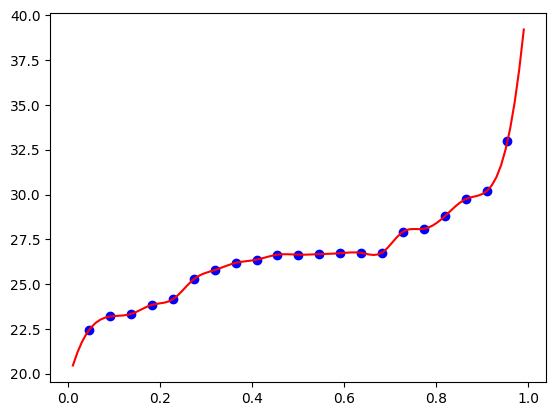

In [5]:
p_range = np.linspace (0.01 , 0.99 , 100)
plt.plot(cprob, max_ord_speeds , 'bo')
plt.plot(p_range, quantile_func(p_range), 'r-')

2\. **Curve fitting of temperature in Alaska** 

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?

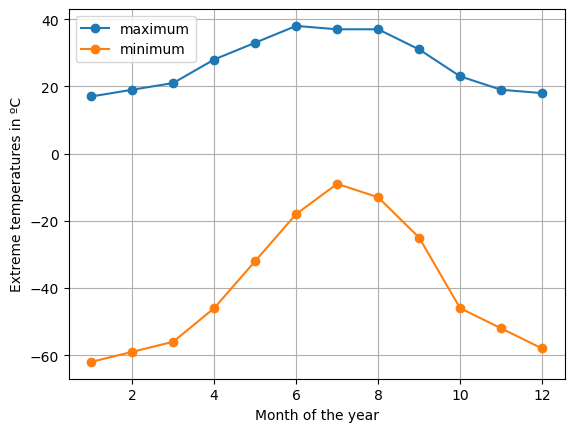

In [107]:
max_temp = [17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18]
min_temp = [-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58]
month = np.arange(1,13)

#Plot these temperature extremes

plt.plot(month,max_temp,marker='o',label="maximum")
plt.plot(month,min_temp,marker='o',label="minimum")
plt.ylabel("Extreme temperatures in ºC")
plt.xlabel("Month of the year")
plt.legend()
plt.grid(True)
plt.show()

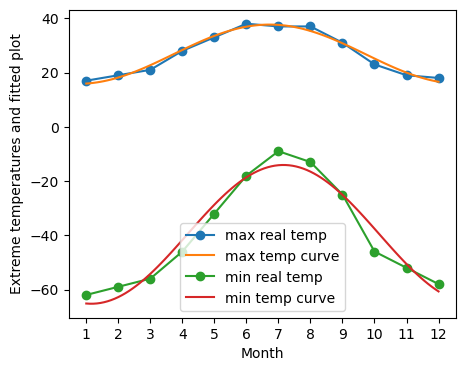

In [131]:
#Define a function that can describe min and max temperatures.
def temp_func(month,avg,amp,offset):
    T = avg + amp*np.cos(month*2*np.pi/12 + offset)
    return T
#avg = temperatura média anual
#amp = amplitude da variação sazonal
#offset = descolamento de fase

# Fit this function to the data with scipy.optimize.curve_fit()
#for max temps:
max_popt, _ = optimize.curve_fit(temp_func, month, max_temp)
#for min temps:
min_popt, _ = optimize.curve_fit(temp_func, month, min_temp)
max_popt,min_popt # are the values for the parameters avg,ampl,offset. 
# That is why month must be the first parameter when defining temps! o primeiro é independente os outros devem ser ajustados

#Plot the result.
plt.figure(figsize=(5,4))
plt.plot(month, max_temp, marker='o',label='max real temp')
plt.plot(np.linspace(1,12,100), temp_func(np.linspace(1,12,100), *max_popt),label='max temp curve')
plt.plot(month, min_temp,marker='o',label='min real temp')
plt.plot(np.linspace(1,12,100), temp_func(np.linspace(1,12,100), *min_popt),label='min temp curve')
plt.xlabel('Month')
plt.xticks(np.arange(1,13))
plt.ylabel('Extreme temperatures and fitted plot')
plt.legend()
plt.show()

#### Is the fit reasonable? If not, why?
The sinusoidal fit is reasonable as a first-order model because monthly temperatures are dominated by an annual periodic cycle. However, it is not expected to be perfect since real climate data is not purely sinusoidal: warming and cooling can be asymmetric and monthly extremes include weather variability, so deviations from a smooth cosine curve are normal.

In [166]:
# Is the time offset for min and max temperatures the same within the fit accuracy?
max_popt, max_pcov = optimize.curve_fit(temp_func, month, max_temp)
min_popt, min_pcov = optimize.curve_fit(temp_func, month, min_temp)

# parâmetros
avg_max, ampl_max, off_max = max_popt
avg_min, ampl_min, off_min = min_popt

# incertezas (1 sigma)
max_perr = np.sqrt(np.diag(max_pcov))
min_perr = np.sqrt(np.diag(min_pcov))

off_max_err = max_perr[2]
off_min_err = min_perr[2]

# diferença e erro combinado
diff = off_max - off_min
combined_err = np.sqrt(off_max_err**2 + off_min_err**2)

print("offset_max =", f"{off_max:.3f}", "+/-", f'{off_max_err:.3f}')
print("offset_min =", f"{off_min:.3f}", "+/-", f"{off_min_err:.3f}")
print("diff =", f'{diff:.3f}', "combined_err =", f'{combined_err:.3f}')
print("The fitted phase offsets differ by more than the combined uncertainty,\nso the timing of min and max is not the same within fit accuracy, indicating a measurable phase shift.")


offset_max = 12.188 +/- 0.052
offset_min = 52.802 +/- 0.071
diff = -40.614 combined_err = 0.087
The fitted phase offsets differ by more than the combined uncertainty,
so the timing of min and max is not the same within fit accuracy, indicating a measurable phase shift.


3\. **2D minimization of a six-hump camelback function**

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many global minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?


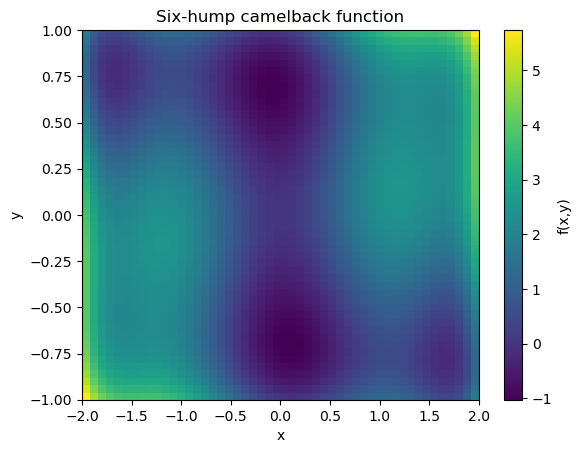

In [211]:
def camelf(x,y):
    f = (4-(2.1*x**2)+(x**4)/3)*(x**2)+x*y+((4*y**2)-4)*y**2
    return f

x = np.linspace(-2, 2) #restriciton
y = np.linspace(-1, 1)
xp, yp = np.meshgrid(x, y)
plt.figure()
plt.imshow(camelf(xp,yp), extent=[-2, 2, -1, 1], origin='lower', aspect='auto')
plt.colorbar(label="f(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Six-hump camelback function")
plt.show()

In [2]:
initial_guesses = [
    (0,0),
    (1,0),
    (-1,0),
    (1,0.5),
    (-1,-0.5)]

results = []

for guess in initial_guesses:
    x_min = optimize.minimize(lambda p: camelf(p[0], p[1]), guess)
    results.append(x_min)
print(results)
print(x_min.x)


NameError: name 'optimize' is not defined

The six-hump camelback function exhibits two global minima located symmetrically at approximately (±0.0898, ∓0.7127), where the function value is about −1.0316. When using different initial guesses, the optimization algorithm converges either to these global minima or to a local minimum at the origin. In particular, an initial guess of (0,0) leads to convergence to a local minimum with f(0,0)=0, illustrating the strong dependence of local optimization methods on the initial conditions for non-convex functions.

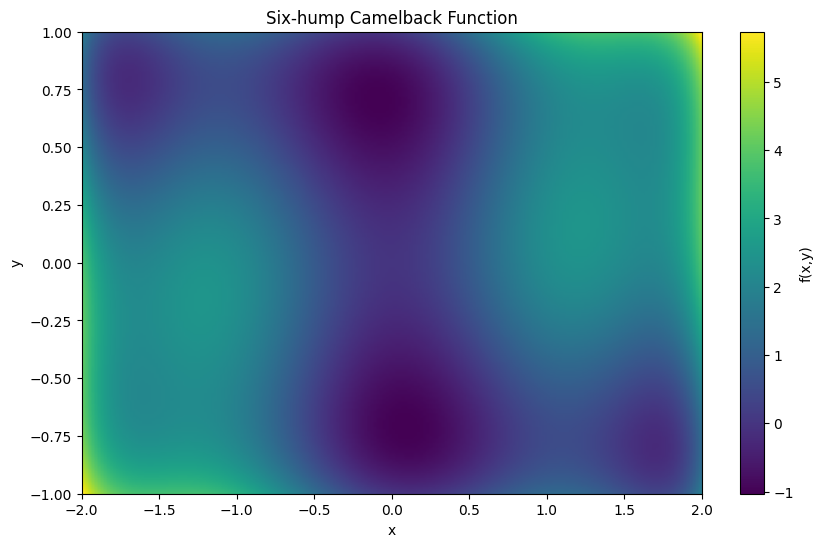

=== Finding minima ===
Start (-1, 0.5) -> x=(-0.0898, 0.7127), f=-1.031628
Start (1, -0.5) -> x=(0.0898, -0.7127), f=-1.031628
Start (-1, -0.5) -> x=(0.0898, -0.7127), f=-1.031628
Start (1, 0.5) -> x=(-0.0898, 0.7127), f=-1.031628
Start (0, 0) -> x=(0.0000, 0.0000), f=0.000000

=== Global minima ===
Number of global minima: 4
Function value: -1.031628
  Location: (-0.0898, 0.7127)
  Location: (0.0898, -0.7127)
  Location: (0.0898, -0.7127)
  Location: (-0.0898, 0.7127)


In [6]:
# === VERSION 2: Exercise 3 - Six-hump Camelback Function ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the function
def camelback(xy):
    x, y = xy
    return (4 - 2.1*x**2 + x**4/3) * x**2 + x*y + (4*y**2 - 4) * y**2

# Create grid for visualization
x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)
Z = camelback([X, Y])

# Plot to find minima visually
plt.figure(figsize=(10, 6))
plt.imshow(Z, extent=[-2, 2, -1, 1], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Six-hump Camelback Function')
plt.show()

# Find minima from different starting points
starting_points = [(-1, 0.5), (1, -0.5), (-1, -0.5), (1, 0.5), (0, 0)]

print("=== Finding minima ===")
results = []
for p0 in starting_points:
    res = minimize(camelback, p0, method='BFGS')
    results.append((res.x, res.fun))
    print(f"Start {p0} -> x=({res.x[0]:.4f}, {res.x[1]:.4f}), f={res.fun:.6f}")

# Find global minimum
min_val = min(r[1] for r in results) #r[1] is the function value, r[0] is the location pq eh onde a funcao eh minima
global_minima = [r for r in results if np.isclose(r[1], min_val, atol=1e-5)]

print(f"\n=== Global minima ===")
print(f"Number of global minima: {len(global_minima)}")
print(f"Function value: {min_val:.6f}")
for gm in global_minima:
    print(f"  Location: ({gm[0][0]:.4f}, {gm[0][1]:.4f})")

# Answer: 2 global minima at ~(±0.0898, ∓0.7126) with f ≈ -1.0316
# Starting at (0,0) leads to a LOCAL minimum (not global!)

4\. **FFT of a simple dataset**

Performe a periodicity analysis on the lynxs-hares population

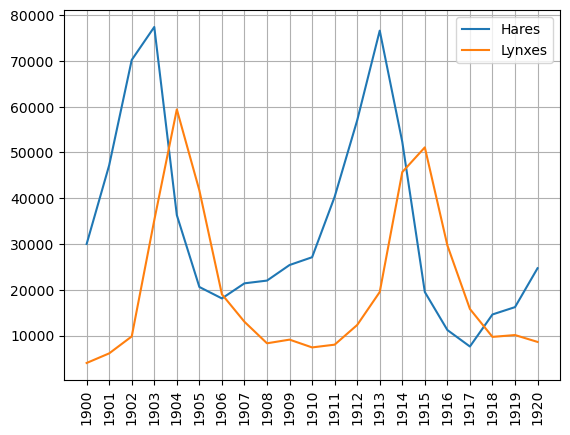

In [267]:
#Encontrar a periodicidade dominante nas populações de hares e lynxes usando FFT.
data = np.loadtxt('populations.txt')
year, hares, lynxes, carrots = data.T

#Plotar os dados para observação
plt.plot(year, hares, label = 'Hares')
plt.plot(year, lynxes, label = 'Lynxes')
plt.xticks(year.astype(int),rotation=90)
plt.grid(True)
plt.legend()
plt.show()

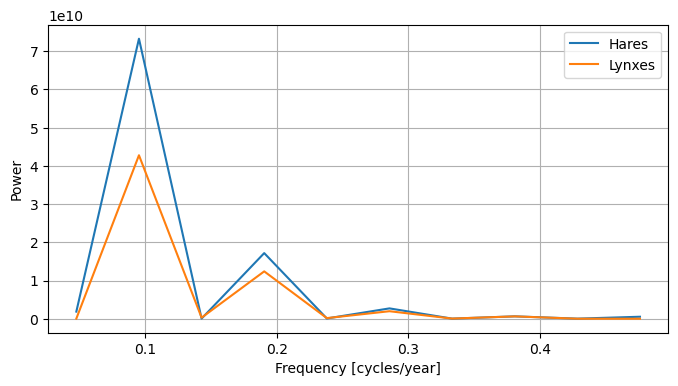

10.5 10.5


In [279]:
#Remover média: A FFT detecta oscilações — a média cria um pico falso em frequência zero.
#A média é um componente DC (frequência zero). FFT interpreta a média como: f=0; se não removido, o pico domina o espectro
#Esse pico não representa periodicidade, só deslocamento vertical
hares_d = hares - np.mean(hares)
lynxes_d = lynxes - np.mean(lynxes)

#Calcular a FFT
#A FFT escreve o sinal como soma de senos e cossenos:
hares_fft = fftpack.fft(hares_d)
lynxes_fft = fftpack.fft(lynxes_d)

#Frequencia associada a amostra; d=1 pois um ano
#a frequencia retornada é de f=ciclos/ano
sample_freq = fftpack.fftfreq(year.size, d=1)

#Expectro de potencia:A periodicidade aparece na magnitude da FFT:
#indica quão forte cada frequencia é. amplitude grande → ciclo importante; amplitude pequena → ruído
#os picos observados são correspondente as potencias
power_hares = np.abs(hares_fft)**2
power_lynxes = np.abs(lynxes_fft)**2

#Como FFT é simétrica, usar apenas frequências positivas, implementando uma mask
mask = sample_freq > 0
freq_p = sample_freq[mask]
power_hares_p = power_hares[mask]
power_lynxes_p = power_lynxes[mask]

#Plotar os graficos de freqxpower
plt.figure(figsize=(8,4))
plt.plot(freq_p, power_hares_p, label='Hares')
plt.plot(freq_p, power_lynxes_p, label='Lynxes')
plt.xlabel("Frequency [cycles/year]")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

#Frequencia de dominancia: o maior pico no espectro indica o ciclo que mais contribui para o sinal
f_dom_hares = freq_p[np.argmax(power_hares_p)]
f_dom_lynxes = freq_p[np.argmax(power_lynxes_p)]
#O período é o inverso da frequencia
T_hares = 1 / f_dom_hares
T_lynxes = 1 / f_dom_lynxes
print(T_lynxes, T_hares)

#há varios picos de frequencias demonstrados no graf. a interpretação é de que o maior pico corresponde a frequencia de maior
#representação; ex: há tb ocorrencia de freq = 0.2 ou um ciclo a cada 5 anos, mas não é tão determinante para descrever o comportamento

5\. **FFT of an image**

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

Text(0.5, 1.0, 'FFT')

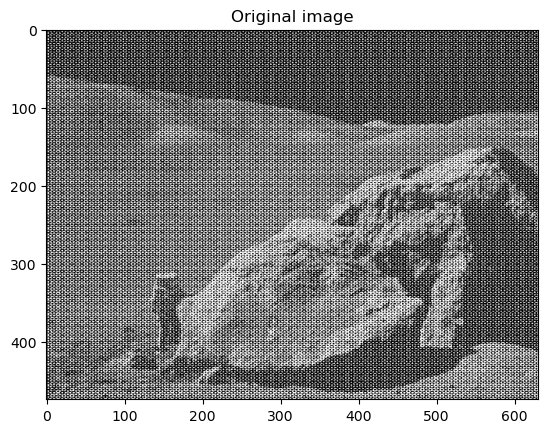

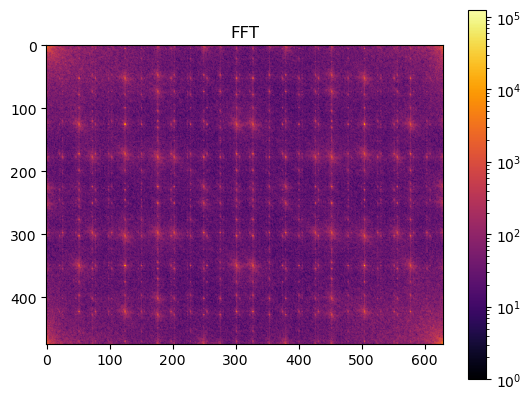

In [287]:
#Loading the image
im = plt.imread('moonlanding.png').astype(float)
plt.imshow(im, plt.cm.gray)
plt.title('Original image')

# Do you have any trouble visualising the spectrum? If so, why?
# Yes, to fix it we use a logarithmic colormap
im_fft = fftpack.fft2(im)
plt.figure()
plt.imshow(np.abs(im_fft), norm=LogNorm(vmin=1), cmap='inferno')
plt.colorbar()
plt.title('FFT')

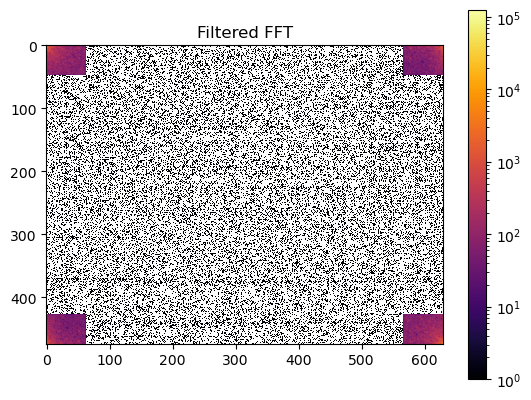

In [313]:
# The spectrum consists of high and low frequency components. 
# The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).

im_fft_filtered = im_fft.copy()
rows,cols = im_fft_filtered.shape

# Noise is in the center, so we define a "margin" for the corners.
# This will leave the bright spots in the corners  visible.
crow, ccol = int(rows*0.1), int(cols*0.1) 

# Set to zero everything that is not on the corners
im_fft_filtered[crow:-crow, :] = 0 #algunas filas, todas las columnas
im_fft_filtered[:, ccol:-ccol] = 0 #todas las filas, algunas columnas

plt.imshow(np.abs(im_fft_filtered), norm=LogNorm(vmin=1), cmap='inferno')
plt.title('Filtered FFT')
plt.colorbar()

Text(0.5, 1.0, 'Reconstructed Image')

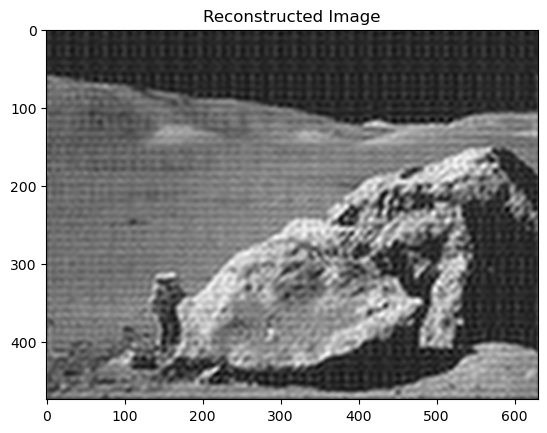

In [315]:
# Apply the inverse Fourier transform

new_im = fftpack.ifft2(im_fft_filtered).real

plt.figure()
plt.imshow(new_im, plt.cm.gray)
plt.title('Reconstructed Image')